# Imports

In [1]:
import os
import sys
import requests
from io import BytesIO
from PIL import Image
from datasets import load_dataset
from tqdm import tqdm
from contextlib import redirect_stdout, redirect_stderr


import argparse
import time
import json
from pathlib import Path
import subprocess
import shutil
import re


import cv2
from datasets import load_dataset


import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    ConfusionMatrixDisplay
)



/home/glados/miniconda3/envs/jpeg_ai_mod/lib/python3.10/site-packages/torch/cuda/__init__.py:61: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


In [ ]:
sys.path.append(str(Path.cwd().parent / "models"))
import NPRDeepfakeDetection as npr
import UniversalFakeDetect as ufd
import CNNDetection as cnnd
# import AIDE
import TruFor

In [3]:
sys.path.insert(0, str("../JPEGAI/"))

In [4]:

from src.codec import get_downloader
from src.codec.common import Image as JAImage
from src.codec.coders import CodecEncoder, CodecDecoder
from src.reco.coders.decoder import process_decoder, RecoDecoder
from src.codec.coders import (
    def_encoder_base_parser,
    def_decoder_base_parser, 
    def_encoder_parser_decorator, 
    def_decoder_parser_decorator
)

from src.reco.coders.decoder import RecoDecoderProcess
from src.reco.coders.encoder import RecoEncoderProcess


# Globals

In [13]:
SAMPLE_NUM = 200
DOWNLOAD = False

In [14]:
DATA_NAME = "data"
DATA_DIR = f"{os.getcwd()}/{DATA_NAME}"
TMP_DIR = f"{os.getcwd()}/tmp"
COMPRESSOR_DIR = Path("../JPEGAI").resolve()

In [ ]:
MODEL_DIR = f"{Path.cwd().parent}/models"

In [16]:
RESULTS_DIR = f"{os.getcwd()}/results"

In [ ]:
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)

In [18]:
bpp_list = ["100", "50", "25", "75"]

In [19]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

In [20]:
EVAL_TEST_SPLIT = 0.05

# Utils

In [21]:
def list_images(input_dir):
    for root, _, files in os.walk(input_dir):
        for file in files:
            files.sort()
            if os.path.splitext(file)[1].lower() == '.png':
                yield os.path.join(root, file)

In [22]:
def list_bits(input_dir):
    for root, _, files in os.walk(input_dir):
        files.sort()
        for file in files:
            yield os.path.join(root, file)

In [23]:
def run_compressor_encoder(input_dir, bpp="25"):
    reco = RecoEncoderProcess(None)
    for image_path in tqdm(list(list_images(input_dir)), desc=f"Encodind from {input_dir} at BPP={bpp}"):

        rel = os.path.relpath(image_path, input_dir)
        name = os.path.splitext(rel)[0]

        bin_path = os.path.join(f"{DATA_DIR}/0_tmp", name)

        os.makedirs(os.path.dirname(bin_path), exist_ok=True)

        cmd_args = [
            image_path,
            bin_path,
            "--set_target_bpp", str(bpp),
            "--models_dir_name", f"{COMPRESSOR_DIR}/models",
            "--gpu", "0",
        ]
        
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull), redirect_stderr(devnull):
                reco.process(cmd_args)

In [24]:
def run_compressor_decoder(output_dir):
    input_dir = f"{DATA_DIR}/0_tmp"
    reco = RecoDecoderProcess(None)
    for data_path in tqdm(list(list_bits(input_dir)), desc=f"Decodin to {output_dir}"):
        
        rel = os.path.relpath(data_path, input_dir)
        name = os.path.splitext(rel)[0]
        
        output_path = os.path.join(output_dir, name + '.png')

        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        cmd_args = [
            data_path,
            output_path,
            "--models_dir_name", f"{COMPRESSOR_DIR}/models",
            "--gpu", "0",
        ]
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull), redirect_stderr(devnull):
                reco.process(cmd_args)
    shutil.rmtree(input_dir)

In [25]:
def compress_directory(input_dir, bpp="25"):
    run_compressor_encoder(f"{DATA_DIR}/{input_dir}", bpp=bpp)
    run_compressor_decoder(f"{DATA_DIR}/{input_dir}{bpp}")

In [26]:
def compress_train_dir(bpp):
    
    offsets = {
        "25":0,
        "50":1,
        "75":2,
        "100":3
    }
    
    rate = 20
    input_dir = f"{DATA_DIR}/_train"
    reco = RecoEncoderProcess(None)
    cnt = 0
    for image_path in tqdm(list(list_images(input_dir)), desc=f"Encodind from {input_dir} at BPP={bpp}"):
        if (cnt + offsets[bpp]) % rate != 0:
            cnt += 1
            continue
        rel = os.path.relpath(image_path, input_dir)
        name = os.path.splitext(rel)[0]

        bin_path = os.path.join(f"{DATA_DIR}/0_tmp", name)

        os.makedirs(os.path.dirname(bin_path), exist_ok=True)

        cmd_args = [
            image_path,
            bin_path,
            "--set_target_bpp", str(bpp),
            "--models_dir_name", f"{COMPRESSOR_DIR}/models",
            "--gpu", "0",
        ]
        
        with open(os.devnull, "w") as devnull:
            with redirect_stdout(devnull), redirect_stderr(devnull):
                reco.process(cmd_args)
        cnt += 1
    run_compressor_decoder(f"{input_dir}_compressed")

In [27]:
def inference(model, loader, name):
    preds = []
    labels = []
    with torch.no_grad():
        for imgs, y in tqdm(loader, desc=f"{name}"):
            imgs = imgs.cuda()

            logits = model(imgs)
            probs = torch.sigmoid(logits)

            preds.extend(probs.flatten().cpu().numpy())
            labels.extend(y.numpy())

    return np.array(preds), np.array(labels)

In [28]:
def printResults(res):
    for key in res.keys():
        print("=========", key, "=========")
        for k in res[key].keys():
            print(k, ": ", res[key][k])
        print('\n')

# Dataset


In [29]:
if DOWNLOAD:
    generators = {1, 3, 7}

    out_dir = Path(f"{DATA_DIR}/tinygenimage")
    out_dir.mkdir(exist_ok=True)
    os.makedirs(f"{out_dir.resolve()}/0_real", exist_ok=True)
    os.makedirs(f"{out_dir.resolve()}/1_fake", exist_ok=True)

    dataset = load_dataset("TheKernel01/Tiny-GenImage", )

    count = 0

    for split in dataset:
        for sample in tqdm(dataset[split], desc=split):

            if sample["generator"] not in generators:
                continue

            image = sample["image"]

            if image.size != (256, 256):
                shutil.rmtree()
                continue

            if sample['label'] == 0:
                subdir = "0_real"
            else:
                subdir = "1_fake"

            image.save(out_dir / subdir / f"{count:06d}.png")
            count += 1
    print("Saved:", count)

In [30]:
if DOWNLOAD:
    for dataset in ['whichfaceisreal', 'seeingdark', 'crn', 'imle', 'san']:
        shutil.rmtree(f"{DATA_DIR}/{dataset}")

In [31]:
if DOWNLOAD:    
    os.makedirs(f"{DATA_DIR}/trash")
    datasetList = ["stylegan", "stylegan2", "progan", 'deepfake', 'cyclegan']
    moved = 0
    rm_cnt = 0
    for data in datasetList:
        origin = Path(f"{DATA_DIR}/{data}").resolve()

        real_dir = origin / "0_real"
        fake_dir = origin / "1_fake"

        real_dir.mkdir(parents=True, exist_ok=True)
        fake_dir.mkdir(parents=True, exist_ok=True)

        for file in origin.rglob("*"):
            if not file.is_file():
                continue
            remove = False
            try: 
                with Image.open(file) as img: 
                    if img.size != (256, 256): 
                        shutil.move(file, f"{DATA_DIR}/trash")
                        rm_cnt += 1
                        continue
            except Exception:
                continue

            parent_name = file.parent.name.lower()

            if parent_name == "0_real":
                dst = real_dir / f"{moved}_{data}.png"
            elif parent_name == "1_fake":
                dst = fake_dir / f"{moved}_{data}.png"
            else:
                continue

            
            shutil.move(file, dst)
            moved += 1
            
        print(f"[{data}]> Moved: {moved}")
        print(f"[{data}]> Removed: {rm_cnt}")
    shutil.rmtree(f"{DATA_DIR}/trash")
    for data in datasetList:
        for d in os.listdir(f"{DATA_DIR}/{data}"):
            if d != '0_real' and d != "1_fake":
                print(f"{DATA_DIR}/{data}/{d}", "removed")
                shutil.rmtree(f"{DATA_DIR}/{data}/{d}")
        


In [32]:

REMOVAL = False

if DOWNLOAD:
    os.makedirs(f"{DATA_DIR}/_train", exist_ok=True)
    os.makedirs(f"{DATA_DIR}/_test", exist_ok=True)
    os.makedirs(f"{DATA_DIR}/_val", exist_ok=True)

    for split in ['_train', '_test', '_val']:
        os.makedirs(f"{DATA_DIR}/{split}/0_real", exist_ok=True)
        os.makedirs(f"{DATA_DIR}/{split}/1_fake", exist_ok=True)
    
    id = 0
    
    spread = {
        "train":0,
        "test":0,
        "val":0,
    }
    
    folder_list = [
        'biggan', 
        'cyclegan', 
        'gaugan', 
        'progan', 
        'stargan', 
        'stylegan', 
        'stylegan2', 
        'tinygenimage',
        'deepfake'
    ]
    
    for folder in folder_list:
        if folder not in os.listdir(f"{DATA_DIR}"):
            continue
        root = f"{DATA_DIR}/{folder}"
        for data_class in ['0_real', '1_fake']:
            target_folder = f'{root}/{data_class}'
            
            files = os.listdir(target_folder)
            
            split_num = round(len(files)*EVAL_TEST_SPLIT)
            cnt = 0
            for img in tqdm(files, desc=f"{folder}:{data_class}"):
                if cnt < split_num:
                    shutil.copy2(
                        f"{target_folder}/{img}", 
                        f"{DATA_DIR}/_val/{data_class}/{folder}_{id}.png"
                    )
                    spread['val'] += 1
                elif cnt < split_num*2:
                    shutil.copy2(
                        f"{target_folder}/{img}", 
                        f"{DATA_DIR}/_test/{data_class}/{folder}_{id}.png"
                    )
                    spread['test'] += 1
                else:
                    shutil.copy2(
                        f"{target_folder}/{img}", 
                        f"{DATA_DIR}/_train/{data_class}/{folder}_{id}.png"
                    )
                    spread['train'] += 1
                cnt += 1
                id += 1
        if REMOVAL:
            shutil.rmtree(root)
    print("Total samples: ", {cnt})
    print(spread)
    

In [ ]:

if DOWNLOAD or False:

    direc = "_test"

    for bpp in bpp_list:
        compress_directory(direc, bpp=bpp)

Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_test at BPP=100:  14%|█▍        | 359/2513 [35:06<3:25:29,  5.72s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_test at BPP=100:  21%|██        | 519/2513 [50:35<2:59:20,  5.40s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_test at BPP=100:  21%|██▏       | 539/2513 [52:33<3:18:15,  6.03s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_test at BPP=100:  31%|███       | 768/2513 [1:15:14<3:01:07,  6.23s/it]libpng warning: iCCP: profile 'ICC Profile': 'desc': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'wtpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP

In [40]:
if DOWNLOAD or False:

    direc = "_val"

    for bpp in bpp_list:
        compress_directory(direc, bpp=bpp)

Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_val at BPP=100:   6%|▌         | 148/2513 [14:25<3:40:44,  5.60s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_val at BPP=100:   7%|▋         | 168/2513 [16:23<3:42:53,  5.70s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_val at BPP=100:  15%|█▍        | 376/2513 [36:20<3:18:55,  5.59s/it]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_val at BPP=100: 100%|██████████| 2513/2513 [4:03:19<00:00,  5.81s/it]  
Decodin to /home/glados/desktop/Universita/CV_proj/project/data/_val100: 100%|██████████| 2513/2513 [26:52<00:00,  1.56it/s]
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_val at BPP=50:   6%

In [ ]:
if DOWNLOAD or False:
    for bpp in bpp_list:
        compress_train_dir(bpp)

Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_train at BPP=100:   7%|▋         | 3258/45223 [15:37<3:43:12,  3.13it/s]libpng warning: iCCP: profile 'ICC Profile': 1000000h: invalid rendering intent
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_train at BPP=100:  14%|█▎        | 6158/45223 [29:44<3:04:41,  3.53it/s]libpng warning: iCCP: profile 'ICC Profile': 48104586h: profile too long
Encodind from /home/glados/desktop/Universita/CV_proj/project/data/_train at BPP=100:  16%|█▌        | 7258/45223 [35:09<2:54:18,  3.63it/s]libpng warning: iCCP: profile 'ICC Profile': 'desc': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'wtpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'bkpt': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'rXYZ': ICC profile tag start not a multiple of 4
libpng warning: iCCP: profile 'ICC Profile': 'g

In [ ]:
if DOWNLOAD:
    for comp_bpp in ["", "25", "50", "75", "100"]:
        set_name = f"_test{comp_bpp}"
        for class_name in ["0_real", "1_fake"]:
            source_folder = f"{DATA_DIR}/{set_name}/{class_name}"
            if comp_bpp == "":
                target_folder = f"{DATA_DIR}/_train/{class_name}"
            else:
                target_folder = f"{DATA_DIR}/_train_compressed/{class_name}"
            count = 0
            for cnt, img in enumerate(os.listdir(source_folder)):
                if (cnt % 2) == 0:
                    continue
                
                shutil.move(f"{source_folder}/{img}", f"{target_folder}/{img}")
                count += 1
            print(f"{source_folder}->{target_folder}: {count} moved")

/home/glados/desktop/Universita/CV_proj/project/data/_test/0_real->/home/glados/desktop/Universita/CV_proj/project/data/_train/0_real: 546 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test/1_fake->/home/glados/desktop/Universita/CV_proj/project/data/_train/1_fake: 710 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test25/0_real->/home/glados/desktop/Universita/CV_proj/project/data/_train_compressed/0_real: 546 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test25/1_fake->/home/glados/desktop/Universita/CV_proj/project/data/_train_compressed/1_fake: 710 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test50/0_real->/home/glados/desktop/Universita/CV_proj/project/data/_train_compressed/0_real: 546 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test50/1_fake->/home/glados/desktop/Universita/CV_proj/project/data/_train_compressed/1_fake: 710 moved
/home/glados/desktop/Universita/CV_proj/project/data/_test75/0_real->/home/gla

In [37]:
data_filder_list = os.listdir(f"{DATA_DIR}")

data_filder_list.sort()

for folder in data_filder_list:
    if folder in ["_scripts", "unused"]:
        continue
    n_real = len(os.listdir(f"{DATA_DIR}/{folder}/0_real"))
    n_fake = len(os.listdir(f"{DATA_DIR}/{folder}/1_fake"))
    print(f"{folder}: {n_real + n_fake}")

_test: 1257
_test100: 1257
_test25: 1257
_test50: 1257
_test75: 1257
_train: 46479
_train_compressed: 10301
_val: 2513
_val100: 2513
_val25: 2513
_val50: 2513
_val75: 2513


In [38]:
test_normal = ImageFolder(
    f"{DATA_DIR}/_test"
)

test_100 = ImageFolder(
    f"{DATA_DIR}/_test100"
)

test_75 = ImageFolder(
    f"{DATA_DIR}/_test75"
)

test_50 = ImageFolder(
    f"{DATA_DIR}/_test50"
)

test_25 = ImageFolder(
    f"{DATA_DIR}/_test25"
)

test_datasets_dict = {
    "no": test_normal,
    "25": test_25,
    "50": test_50,
    "75": test_75,
    "100": test_100
}

# Benchmark Networks

### NPR

In [ ]:
model = npr.networks.resnet.resnet50(num_classes=1)
state_dict = torch.load(f"{MODEL_DIR}/NPRDeepfakeDetection/NPR.pth", map_location='cpu')

weights = state_dict["model"]

weights = {
    k.replace("module.", ""): v
    for k, v in weights.items()
}

model.load_state_dict(weights)
model.cuda()
model.eval()

/tmp/ipykernel_965508/167656878.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(NPR_DIR, map_location='cpu')


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [60]:
results_npr = {}

In [61]:
npr_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [62]:
for name in test_datasets_dict.keys():
    test_datasets_dict[name].transform = npr_transform
    dataset_loader = DataLoader(
        test_datasets_dict[name],
        batch_size=16,
        shuffle=False,
        num_workers=4
    )
    preds, labels = inference(model, dataset_loader, name)
    pred_labels = (preds > 0.5).astype(int)
    cm = confusion_matrix(labels, pred_labels)

    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "accuracy": accuracy_score(labels, pred_labels),
        "precision": precision_score(labels, pred_labels),
        "recall": recall_score(labels, pred_labels),
        "f1": f1_score(labels, pred_labels),
        "roc_auc": roc_auc_score(labels, preds),
        "avg_prec": average_precision_score(labels, preds),
        "specificity": float(tn / (tn + fp)),
    }
    
    results_npr[name] = metrics
with open(f"{RESULTS_DIR}/npr.json", "w") as f:
    json.dump(results_npr, f)


100: 100%|██████████| 79/79 [00:02<00:00, 30.08it/s]


In [63]:
printResults(results_npr)

========= no =========
TN :  488
FP :  58
FN :  25
TP :  686
accuracy :  0.933969769291965
precision :  0.9220430107526881
recall :  0.9648382559774965
f1 :  0.9429553264604811
roc_auc :  0.9676653632349835
avg_prec :  0.9578317017118089
specificity :  0.8937728937728938


========= 25 =========
TN :  7
FP :  539
FN :  1
TP :  710
accuracy :  0.5704057279236276
precision :  0.5684547638110489
recall :  0.9985935302390999
f1 :  0.7244897959183674
roc_auc :  0.5070606842758741
avg_prec :  0.5691283465396564
specificity :  0.01282051282051282


========= 50 =========
TN :  13
FP :  533
FN :  3
TP :  708
accuracy :  0.573587907716786
precision :  0.5705076551168412
recall :  0.9957805907172996
f1 :  0.7254098360655737
roc_auc :  0.5108872608872609
avg_prec :  0.5710595220823217
specificity :  0.023809523809523808


========= 75 =========
TN :  13
FP :  533
FN :  7
TP :  704
accuracy :  0.5704057279236276
precision :  0.5691188358932903
recall :  0.9901547116736991
f1 :  0.7227926078028748


### UniversalFakeDetector

In [64]:
MEAN = {
    "imagenet":[0.485, 0.456, 0.406],
    "clip":[0.48145466, 0.4578275, 0.40821073]
}

STD = {
    "imagenet":[0.229, 0.224, 0.225],
    "clip":[0.26862954, 0.26130258, 0.27577711]
}

transform_udf =  transforms.Compose([
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=MEAN["clip"],
        std=STD['clip']
    )
])

In [65]:
model = ufd.models.get_model("CLIP:ViT-L/14")
state_dict = torch.load(
    f"{MODEL_DIR}/UniversalFakeDetect/pretrained_weights/fc_weights.pth", 
    map_location='cpu'
)
model.fc.load_state_dict(state_dict)
model.eval()
model.cuda()

/tmp/ipykernel_965508/1914882251.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(


CLIPModel(
  (model): CLIP(
    (visual): VisionTransformer(
      (conv1): Conv2d(3, 1024, kernel_size=(14, 14), stride=(14, 14), bias=False)
      (ln_pre): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
      (transformer): Transformer(
        (resblocks): Sequential(
          (0): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuantizableLinear(in_features=1024, out_features=1024, bias=True)
            )
            (ln_1): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
            (mlp): Sequential(
              (c_fc): Linear(in_features=1024, out_features=4096, bias=True)
              (gelu): QuickGELU()
              (c_proj): Linear(in_features=4096, out_features=1024, bias=True)
            )
            (ln_2): LayerNorm((1024,), eps=1e-05, elementwise_affine=True)
          )
          (1): ResidualAttentionBlock(
            (attn): MultiheadAttention(
              (out_proj): NonDynamicallyQuan

In [66]:
results_ufd = {}

In [ ]:
for name in test_datasets_dict.keys():
    test_datasets_dict[name].transform = transform_udf
    dataset_loader = DataLoader(
        test_datasets_dict[name],
        batch_size=1,
        shuffle=False,
        num_workers=4
    )
    preds, labels = inference(model, dataset_loader, name)
    pred_labels = (preds > 0.5).astype(int)
    cm = confusion_matrix(labels, pred_labels)

    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "accuracy": accuracy_score(labels, pred_labels),
        "precision": precision_score(labels, pred_labels),
        "recall": recall_score(labels, pred_labels),
        "f1": f1_score(labels, pred_labels),
        "roc_auc": roc_auc_score(labels, preds),
        "avg_prec": average_precision_score(labels, preds),
    }
    
    results_ufd[name] = metrics
with open(f"{RESULTS_DIR}/ufd.json", "w") as f:
    json.dump(results_ufd, f)



100: 100%|██████████| 1257/1257 [01:04<00:00, 19.35it/s]


In [68]:
printResults(results_ufd)

========= no =========
TN :  539
FP :  7
FN :  175
TP :  536
accuracy :  0.8552108194112967
precision :  0.9871086556169429
recall :  0.7538677918424754
f1 :  0.8548644338118022
roc_auc :  0.9701138055568435
avg_prec :  0.978804872550725


========= 25 =========
TN :  442
FP :  104
FN :  223
TP :  488
accuracy :  0.7398568019093079
precision :  0.8243243243243243
recall :  0.6863572433192686
f1 :  0.7490406753645433
roc_auc :  0.8329907317249089
avg_prec :  0.8725116981581483


========= 50 =========
TN :  515
FP :  31
FN :  233
TP :  478
accuracy :  0.7899761336515513
precision :  0.9390962671905697
recall :  0.6722925457102672
f1 :  0.7836065573770492
roc_auc :  0.9011246606183315
avg_prec :  0.9313801231001942


========= 75 =========
TN :  521
FP :  25
FN :  218
TP :  493
accuracy :  0.8066825775656324
precision :  0.9517374517374517
recall :  0.6933895921237694
f1 :  0.8022782750203418
roc_auc :  0.921613782373276
avg_prec :  0.9466526946054652


========= 100 =========
TN :  526


### WangCNN Detection

In [69]:
wang_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [70]:
model = cnnd.networks.resnet.resnet50(num_classes=1)
state_dict = torch.load(f"{MODEL_DIR}/CNNDetection/weights/blur_jpg_prob0.5.pth", map_location='cpu')
model.load_state_dict(state_dict['model'])
model.cuda()
model.eval()

/tmp/ipykernel_965508/2421441663.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f"{MODEL_DIR}/CNNDetection/weights/blur_jpg_prob0.5.pth", map_lo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [71]:
results_wang = {}

In [72]:
for name in test_datasets_dict.keys():
    test_datasets_dict[name].transform = wang_transform
    dataset_loader = DataLoader(
        test_datasets_dict[name],
        batch_size=16,
        shuffle=False,
        num_workers=4
    )
    preds, labels = inference(model, dataset_loader, name)
    pred_labels = (preds > 0.5).astype(int)
    cm = confusion_matrix(labels, pred_labels)

    tn, fp, fn, tp = cm.ravel()

    metrics = {
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "accuracy": accuracy_score(labels, pred_labels),
        "precision": precision_score(labels, pred_labels),
        "recall": recall_score(labels, pred_labels),
        "f1": f1_score(labels, pred_labels),
        "roc_auc": roc_auc_score(labels, preds),
        "avg_prec": average_precision_score(labels, preds),
        "specificity": float(tn / (tn + fp)),
    }
    
    results_wang[name] = metrics

with open(f"{RESULTS_DIR}/wang_cnn.json", "w") as f:
    json.dump(results_wang, f)
    



no:   0%|          | 0/79 [00:00<?, ?it/s]

100: 100%|██████████| 79/79 [00:03<00:00, 19.94it/s]


In [73]:
printResults(results_ufd)

========= no =========
TN :  539
FP :  7
FN :  175
TP :  536
accuracy :  0.8552108194112967
precision :  0.9871086556169429
recall :  0.7538677918424754
f1 :  0.8548644338118022
roc_auc :  0.9701138055568435
avg_prec :  0.978804872550725


========= 25 =========
TN :  442
FP :  104
FN :  223
TP :  488
accuracy :  0.7398568019093079
precision :  0.8243243243243243
recall :  0.6863572433192686
f1 :  0.7490406753645433
roc_auc :  0.8329907317249089
avg_prec :  0.8725116981581483


========= 50 =========
TN :  515
FP :  31
FN :  233
TP :  478
accuracy :  0.7899761336515513
precision :  0.9390962671905697
recall :  0.6722925457102672
f1 :  0.7836065573770492
roc_auc :  0.9011246606183315
avg_prec :  0.9313801231001942


========= 75 =========
TN :  521
FP :  25
FN :  218
TP :  493
accuracy :  0.8066825775656324
precision :  0.9517374517374517
recall :  0.6933895921237694
f1 :  0.8022782750203418
roc_auc :  0.921613782373276
avg_prec :  0.9466526946054652


========= 100 =========
TN :  526


### TruFor

In [78]:
configs = TruFor.lib.config.config
model = TruFor.get_model()

AttributeError: module 'TruFor' has no attribute 'lib'

### AIDE

# Frequency Domain Analysis

[ WARN:0@2803.076] global loadsave.cpp:278 findDecoder imread_('/home/glados/desktop/Universita/CV_proj/project/data/compressed_100/0_real_bpp_100/1386553015079.png'): can't open/read file: check file path/integrity


error: OpenCV(4.13.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


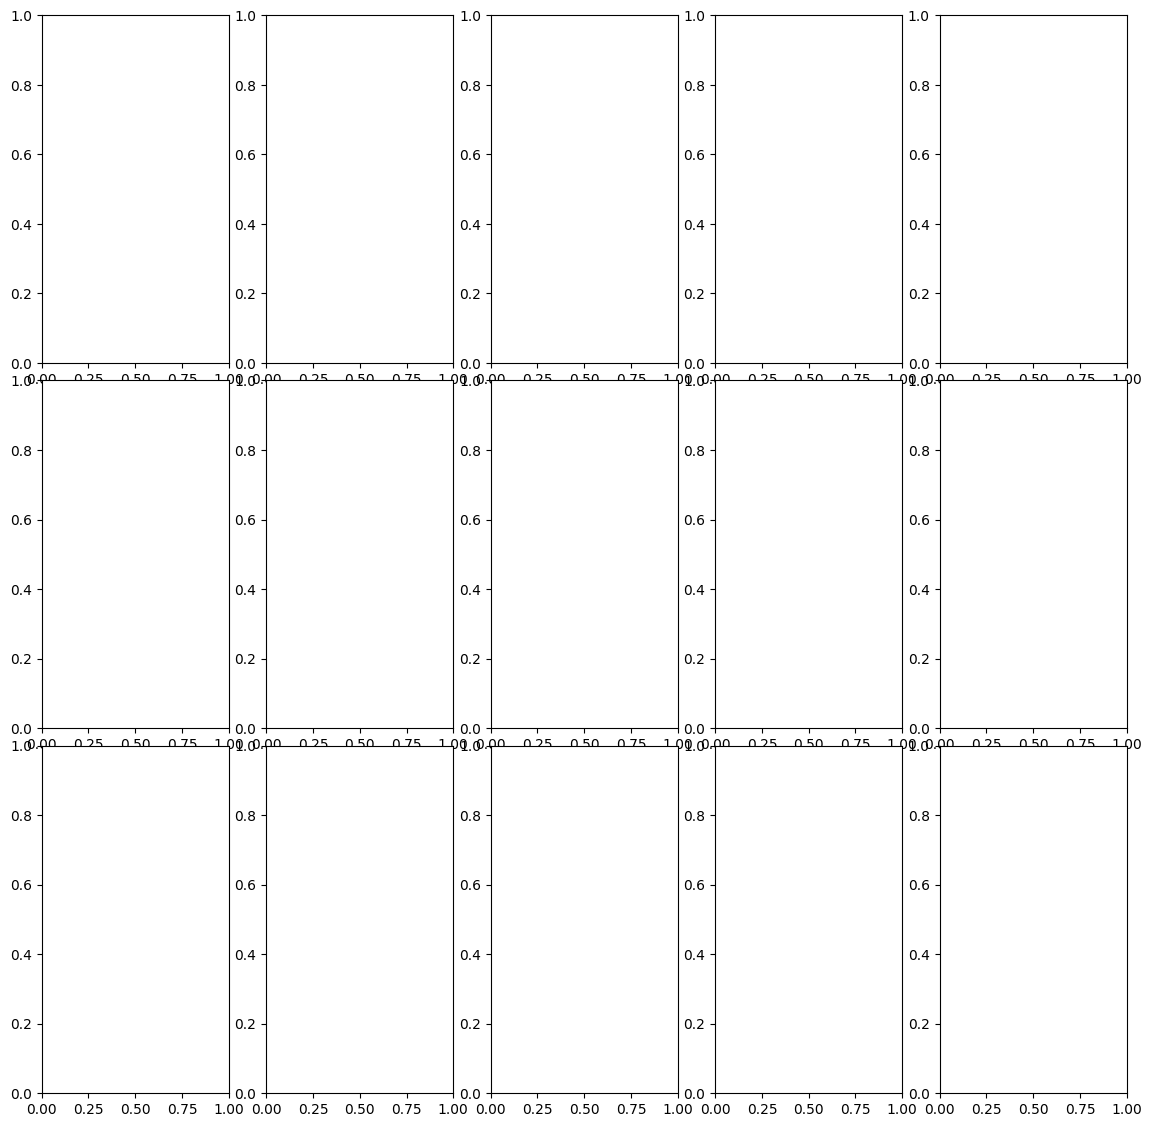

In [74]:
id = "1386553015079"

fake = bool(re.search(r"[0-9]+_gen[0123]", id))

position = 0
original = None

fig, axes = plt.subplots(3, len(bpp_list)+1, figsize=(14, 14))
fig.subplots_adjust(hspace=0.05)

for bpp in bpp_list + ["no"]:

    if fake:
        prefix = "1_fake"
    else:
        prefix = "0_real"

    if bpp == "no":
        prefix = f"{os.getcwd()}/data/uncompressed/{prefix}"
    else:
        prefix = f"{os.getcwd()}/data/compressed_{bpp}/{prefix}_bpp_{bpp}"

    path = f"{prefix}/{id}.png"

    img = cv2.imread(path, cv2.IMREAD_ANYCOLOR)

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    F = np.fft.fft2(gray)
    F_shift = np.fft.fftshift(F)

    magnitude = np.abs(F_shift)

    magnitude = np.log1p(magnitude)

    magnitude = (
        (magnitude - magnitude.min()) /
        (magnitude.max() - magnitude.min() + 1e-8)
    )

    title = "normal" if bpp == "no" else f"BPP={bpp}"

    axes[0, position].imshow(img, aspect='auto')
    axes[0, position].axis('off')
    axes[0, position].set_title(title)

    axes[1, position].imshow(
        magnitude,
        cmap='inferno',
        aspect='auto'
    )
    axes[1, position].axis('off')
    axes[1, position].set_title(title)


    if original is None:
        diff = np.zeros_like(magnitude)
        original = magnitude
    else:
        diff = np.abs(magnitude - original)
        diff = (
            (diff - diff.min()) /
            (diff.max() - diff.min() + 1e-8)
        )

    axes[2, position].imshow(
        diff,
        cmap='inferno',
        aspect='auto'
    )
    axes[2, position].axis('off')
    

    axes[0, position].set_aspect('equal')
    axes[1, position].set_aspect('equal')
    axes[2, position].set_aspect('equal')

    position += 1

plt.show()

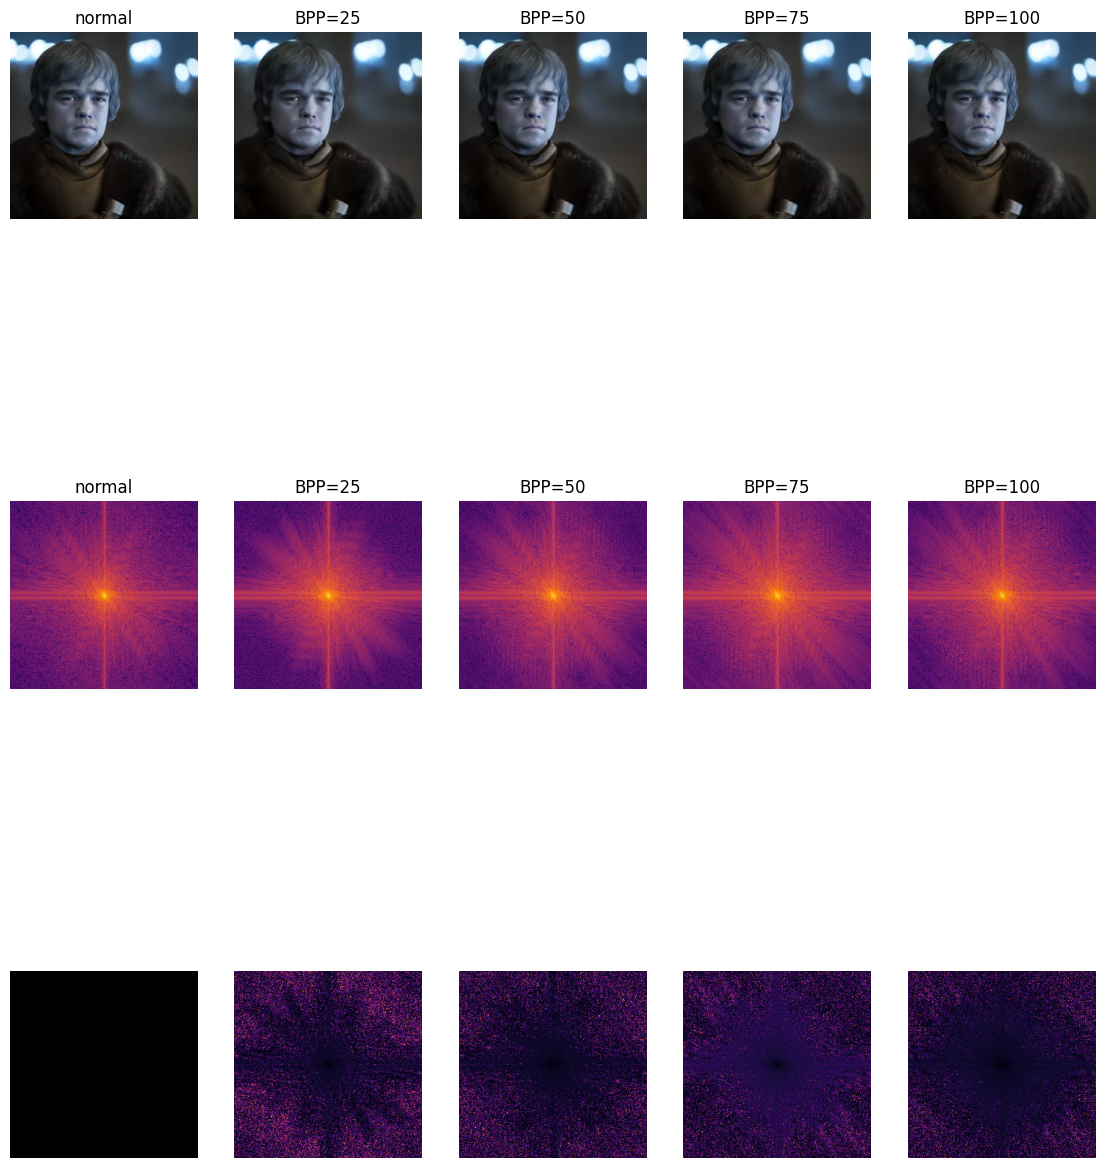

In [ ]:
id = "1386553015079_gen0"

fake = re.search(r"[0-9]*(_gen[0123])|", id)

position = 0
original = None

fig, axes = plt.subplots(3, len(bpp_list)+1, figsize=(14, 14))
fig.subplots_adjust(hspace=0.05)

for bpp in bpp_list + ["no"]:

    if fake:
        prefix = "1_fake"
    else:
        prefix = "0_real"

    if bpp == "no":
        prefix = f"{os.getcwd()}/data/uncompressed/{prefix}"
    else:
        prefix = f"{os.getcwd()}/data/compressed_{bpp}/{prefix}_bpp_{bpp}"

    path = f"{prefix}/{id}.png"

    img = cv2.imread(path, cv2.IMREAD_ANYCOLOR)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    F = np.fft.fft2(gray)
    F_shift = np.fft.fftshift(F)

    magnitude = np.abs(F_shift)

    magnitude = np.log1p(magnitude)

    magnitude = (
        (magnitude - magnitude.min()) /
        (magnitude.max() - magnitude.min() + 1e-8)
    )

    title = "normal" if bpp == "no" else f"BPP={bpp}"

    axes[0, position].imshow(img, aspect='auto')
    axes[0, position].axis('off')
    axes[0, position].set_title(title)

    axes[1, position].imshow(
        magnitude,
        cmap='inferno',
        aspect='auto'
    )
    axes[1, position].axis('off')
    axes[1, position].set_title(title)


    if original is None:
        diff = np.zeros_like(magnitude)
        original = magnitude
    else:
        diff = np.abs(magnitude - original)
        diff = (
            (diff - diff.min()) /
            (diff.max() - diff.min() + 1e-8)
        )

    axes[2, position].imshow(
        diff,
        cmap='inferno',
        aspect='auto'
    )
    axes[2, position].axis('off')


    axes[0, position].set_aspect('equal')
    axes[1, position].set_aspect('equal')
    axes[2, position].set_aspect('equal')

    position += 1

plt.show()

# Train

# Test